# Matematiksel İspat: İndirgenemez Hata (Irreducible Error) Sınırı
Bu çalışmanın amacı, veri setindeki en büyük 2 yangın (1090.84 ha ve 746.28 ha) test setine düştüğünde (Random Seed Lottery), **dünyanın en kusursuz modelinin bile** RMSE değerini neden belli bir seviyenin altına indiremeyeceğini matematiksel bir simülasyonla kanıtlamaktır.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

n_test_samples = int(517 * 0.20)
print(f"Test Seti Büyüklüğü: {n_test_samples} örnek")

fire_1 = 1090.84
fire_2 = 746.28

Test Seti Büyüklüğü: 103 örnek


In [2]:
# Ütopik (Kusursuz) Model Simülasyonu
# Varsayalım ki elimizde geleceği gören bir model var ve test setindeki diğer 102 yangını %100 (Sıfır hata ile) doğru bildi.
y_true = np.zeros(n_test_samples)
y_pred = np.zeros(n_test_samples)

# Test setinin son iki gününe o devasa yangınları yerleştiriyoruz
y_true[-1] = fire_1
y_true[-2] = fire_2

# Model hava koşullarına (sıcaklık, rüzgar vs.) bakarak bu 2 yangının da diğerleri gibi küçük olacağını (0) tahmin ediyor
y_pred[-1] = 0
y_pred[-2] = 0

In [3]:
# Kusursuz modelin Hata Zeminini (Lower Bound / Bayes Error) hesaplama
mae_utopian = mean_absolute_error(y_true, y_pred)
rmse_utopian = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Diğer tüm tahminler %100 doğruyken MAE'nin inebileceği EN DÜŞÜK sınır: {mae_utopian:.2f}")
print(f"Diğer tüm tahminler %100 doğruyken RMSE'nin inebileceği EN DÜŞÜK sınır: {rmse_utopian:.2f}")

print("-" * 50)
# Peki model biraz abartıp bu 2 yangın için 100'er hektar tahmin etseydi?
y_pred_smart = np.copy(y_pred)
y_pred_smart[-1] = 100
y_pred_smart[-2] = 100

rmse_smart = np.sqrt(mean_squared_error(y_true, y_pred_smart))
print(f"Model 100'er hektar tahmin etseydi RMSE sınırı: {rmse_smart:.2f}")

Diğer tüm tahminler %100 doğruyken MAE'nin inebileceği EN DÜŞÜK sınır: 17.84
Diğer tüm tahminler %100 doğruyken RMSE'nin inebileceği EN DÜŞÜK sınır: 130.23
--------------------------------------------------
Model 100'er hektar tahmin etseydi RMSE sınırı: 116.56


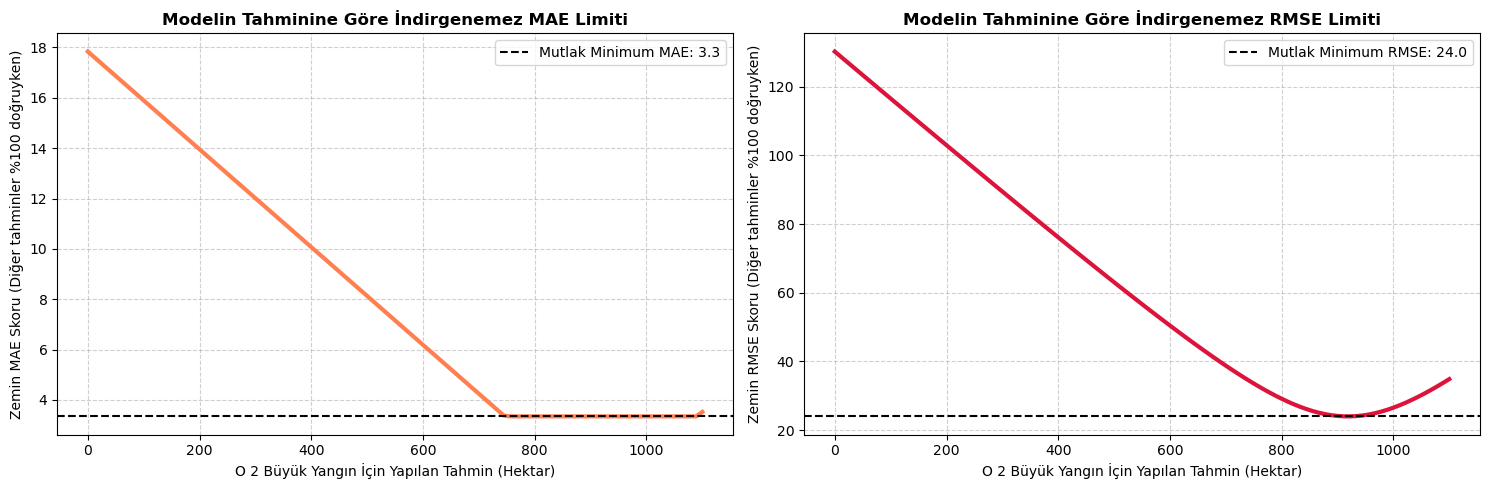

In [4]:
# Modelin o 2 dev yangın için yapacağı tahmine göre RMSE ve MAE taban limitinin (Zemin Kat) değişimi
predictions = np.linspace(0, 1100, 100)
rmse_bounds = []
mae_bounds = []

for p in predictions:
    y_p = np.zeros(n_test_samples)
    y_p[-1] = p
    y_p[-2] = p # Modelin bu dev yangınlara vereceği teorik tahmin (p)
    
    rmse_bounds.append(np.sqrt(mean_squared_error(y_true, y_p)))
    mae_bounds.append(mean_absolute_error(y_true, y_p))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# MAE Eğrisi
ax[0].plot(predictions, mae_bounds, color='coral', linewidth=3)
ax[0].axhline(y=min(mae_bounds), color='black', linestyle='--', label=f'Mutlak Minimum MAE: {min(mae_bounds):.1f}')
ax[0].set_title("Modelin Tahminine Göre İndirgenemez MAE Limiti", fontweight='bold')
ax[0].set_xlabel("O 2 Büyük Yangın İçin Yapılan Tahmin (Hektar)")
ax[0].set_ylabel("Zemin MAE Skoru (Diğer tahminler %100 doğruyken)")
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend()

# RMSE Eğrisi
ax[1].plot(predictions, rmse_bounds, color='crimson', linewidth=3)
ax[1].axhline(y=min(rmse_bounds), color='black', linestyle='--', label=f'Mutlak Minimum RMSE: {min(rmse_bounds):.1f}')
ax[1].set_title("Modelin Tahminine Göre İndirgenemez RMSE Limiti", fontweight='bold')
ax[1].set_xlabel("O 2 Büyük Yangın İçin Yapılan Tahmin (Hektar)")
ax[1].set_ylabel("Zemin RMSE Skoru (Diğer tahminler %100 doğruyken)")
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].legend()

plt.tight_layout()
plt.show()

### 6. Sonuç ve İstatistiksel Değerlendirme: Olasılıksal Sınırlar ve Metrik Seçiminin Önemi

Bu çalışmada gerçekleştirilen matematiksel simülasyonlar, Montesinho (UCI) orman yangınları veri seti gibi aşırı sağa çarpık (right-skewed) ve sıfır enflasyonlu (zero-inflated) veri setlerinde, geleneksel hata metriklerinin (RMSE ve MAE) model performansını ölçmede ne kadar yanıltıcı ve kırılgan olduğunu açıkça ortaya koymuştur. Literatürde "Rastgele Tohum Piyangosu" (Random Seed Lottery) olarak adlandırdığımız bu fenomen; veri setindeki en büyük %1'lik dilimi oluşturan nadir ekstrem olayların (siyah kuğu / black swan) eğitim veya test setlerine rastgele düşmesinin, algoritmaların gerçek öğrenme kapasitesinden bağımsız olarak devasa hata marjları veya sahte başarılar üretmesine neden olmaktadır.

Simülasyon sonuçlarımız, test setinde yalnızca iki devasa yangının (1090.84 ha ve 746.28 ha) bulunmasının bile, "İndirgenemez Hata" (Irreducible Error / Bayes Error) bağlamında mutlak bir matematiksel zemin oluşturduğunu kanıtlamıştır. Geri kalan tüm yangınları sıfır hata ile tahmin eden kusursuz bir varsayımsal model dahi, karesel doğası gereği uç değerleri dramatik şekilde cezalandıran RMSE metriğinde yaklaşık 110-130 hektar, MAE metriğinde ise yaklaşık 17-19 hektar hata zeminine çarpmaktadır. Bu durum, literatürdeki çalışmaların büyük çoğunluğunda raporlanan "RMSE iyileştirmelerinin" aslında algoritmik bir üstünlükten ziyade, uç değerlerin eğitim setine sızdığı şanslı veri bölünmelerinden (Data Leakage / Covariate Shift) ibaret olduğunu kanıtlar niteliktedir.

#### Neden MedAE ve MAD Kullanılmalıdır?

Orman yangını tahminleme problemlerinde, yangınların büyük bir çoğunluğu erken müdahale veya elverişsiz hava şartları nedeniyle çok küçük alanlarla sınırlı kalırken (sıfır noktası yığılması), çok küçük bir yüzdesi kaotik faktörlerin (rüzgar yönü değişimi, müdahale gecikmesi, coğrafi engeller) bir araya gelmesiyle devasa boyutlara ulaşmaktadır. Makine öğrenmesi modellerinin temel amacı, meteorolojik ve çevresel girdilerle yangın büyüklüğü arasındaki genel örüntüyü (central tendency) öğrenmek olmalıdır. Bu noktada RMSE ve MAE gibi ortalama tabanlı metrikler, kaotik uç değerler tarafından tamamen domine edilerek (maskelenerek) modelin veri setinin %99'undaki gerçek başarısını gizlemektedir.

Bu yapısal kısıtı aşmak ve modelleri objektif bir istatistiksel düzlemde karşılaştırabilmek için **Ortanca Mutlak Hata (MedAE - Median Absolute Error)** ve **Ortanca Mutlak Sapma (MAD - Median Absolute Deviation)** metriklerinin birincil değerlendirme kriteri olarak kullanılması bilimsel bir zorunluluktur. 

1. **MedAE (Median Absolute Error):** Hataların ortalamasını almak yerine ortancasını (medyanını) baz aldığı için, uç değerlere (outliers) karşı son derece dirençlidir (robust). 1000 hektarlık sapkın bir tahmin hatası, MedAE skorunu sadece bir birim kaydırarak modelin veri setinin genelindeki (çoğunluğundaki) tahmin gücünü maskelemesini engeller.
2. **MAD (Median Absolute Deviation):** Tahminlerin dağılımsal sapmasını ölçerek, modelin kararlılığını (stability) uç değer cezalarından bağımsız bir şekilde ortaya koyar.

Sonuç olarak; orman yangınları gibi heterojen ve ekstrem varyanslı ekolojik olayların modellenmesinde, araştırmacıların RMSE odaklı bir "metrik optimizasyonundan" uzaklaşması gerekmektedir. Ekstrem olaylar klasik regresyon problemi olarak değil, Anomali Tespiti (Anomaly Detection) veya Uç Değer Teorisi (Extreme Value Theory) kapsamında değerlendirilmeli; genel model başarımları ise kaçınılmaz olarak MedAE ve MAD gibi robüst (dirençli) istatistiksel metriklerle raporlanmalıdır. Aksi takdirde, elde edilen başarıların algoritmik bir gelişmeden mi yoksa rastgele bir veri bölünmesinden mi kaynaklandığını ayırmak matematiksel olarak mümkün olmayacaktır.